# Compute tidal disruption radius in GR 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import kerrgeopy as kg
from scipy.optimize import least_squares

#===================================================================== 
# ! IMPORTANT: UPDATE THIS PATH FOR YOUR OWN MACHINE!  
# 
# ➤ Please replace it with the full path to your "WD-IMBH-Relativistic-Tides" folder.
#   Example:
#        sys.path.append("/Users/your_username/your_project_folder/WD-IMBH-Relativistic-Tides")
#
#  Tip: Keep this notebook in the same directory as the "WD-IMBH-Relativistic-Tides" folder for easier path management.
import os 
os.chdir("/your_username/your_project_folder/WD-IMBH-Relativistic-Tides") 
# os.chdir("/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides")
print(os.getcwd())
#==================================================================== 


/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides


In [12]:
# Boundary of unstable orbits
# Original function
for iiii in range(1):
    def Unstable_eq_function(rp, e, a):
        p = rp * (1 + e)
        F = p**(-3) * (
            p**3
            - 2 * (3 + e**2) * p**2
            + (3 + e**2)**2 * p
            - 4 * a**2 * (1 - e**2)**2
        )
        N = 2 / p * (
            -p**2
            + ((3 + e**2) - a**2) * p
            - a**2 * (1 + 3 * e**2)
        )
        C = (a**2 - p)**2
        Delta_x = N**2 - 4 * F * C
        return Delta_x - (2 * F * p**2 / ((1 + e) * (3 - e)) + N)**2

    def F(rp, e, a):
        return Unstable_eq_function(rp, e, a)

    # Compute partial derivatives
    def dF_drp(rp, e, a, h=1e-6):
        return (F(rp + h, e, a) - F(rp - h, e, a)) / (2 * h)

    def dF_de(rp, e, a, h=1e-6):
        return (F(rp, e + h, a) - F(rp, e - h, a)) / (2 * h)

    # Define the right-hand side of the ODE
    def drp_de(e, rp, a):
        """Compute dr_p / de"""
        rp = rp[0]  # scipy.integrate.solve_ivp passes an array
        df_drp = dF_drp(rp, e, a)
        df_de = dF_de(rp, e, a)

        if abs(df_drp) < 1e-12:
            # Derivative near zero → vertical tangent; integration cannot proceed
            return [0.0]

        return [-abs(df_de / df_drp)]

# Integrate using solve_ivp
from scipy.integrate import solve_ivp

def solve_rp_function(a):
    e0 = 0  # Known value of eccentricity e
    # Compute initial rp0
    Z1 = 1 + (1 - a**2)**(1/3) * ((1 + a)**(1/3) + (1 - a)**(1/3))
    Z2 = (3 * a**2 + Z1**2)**(1/2)
    rp0 = 3 + Z2 - np.sign(a) * ((3 - Z1) * (3 + Z1 + 2 * Z2))**(1/2)  # Corresponding correct rp value
    rp0 = rp0 * 1

    # Forward integration to e = 0.999, backward to e = 0.001
    sol_forward = solve_ivp(
        fun=lambda e, y: drp_de(e, y, a),
        t_span=(e0, 0.999),
        y0=[rp0],
        method='RK45',
        max_step=0.01,
        rtol=1e-6,
        atol=1e-10
    )

    sol_backward = solve_ivp(
        fun=lambda e, y: drp_de(e, y, a),
        t_span=(e0, 0.001),
        y0=[rp0],
        method='RK45',
        max_step=0.01,
        rtol=1e-6,
        atol=1e-12
    )

    # Combine results
    e_full = np.concatenate([sol_backward.t[::-1], sol_forward.t[1:]])
    rp_full = np.concatenate([sol_backward.y[0][::-1], sol_forward.y[0][1:]])

    # Create interpolation function
    rp_interp = interp1d(e_full, rp_full, kind='cubic', fill_value="extrapolate")

    return rp_interp

In [13]:
# Define some physical quantities
def WD_R_M(M_WD):  
    return 6120*(M_WD/1.44)**(-1/3)*(1-M_WD/1.44)**(0.447)  
def WD_eta(M_WD): 
    return (M_WD/WD_R_M(M_WD))**(1/2)

In [14]:
#==================================================== 
# Fixed parameters: white dwarf mass and black hole mass
M_WD = 0.6
M_BH = 1e5
R_BH = M_BH  # Resulting unit is in solar gravitational radii (r_g)
R_star = WD_R_M(M_WD)  # Resulting unit is in solar gravitational radii (r_g)
ratio_R_star_R_BH = R_star / R_BH
ratio_sqrt_v_star_c = WD_eta(M_WD)
r_t = ratio_R_star_R_BH * (M_BH / M_WD)**(1/3)  # Newtonian rt

In [15]:
def R_of_r(r, E, L, a):
    """Radial effective potential function R(r) for Kerr geodesics."""
    return -( ((-a * E + L)**2 + r**2) * (a**2 - 2*r + r**2)
            ) + (-a * L + E * (a**2 + r**2))**2 

# Solve for energy E and angular momentum L given pericenter (rp) and apocenter (ra)
def solve_EL_from_rp_ra(rp, ra, a, E0, L0):
    # Reasonable bounds for energy E (bound orbits have 0 < E < 1, but allow margin)
    E_low, E_high = 0.1, 15
    
    # Search range for angular momentum L (always positive in this convention)
    L_low, L_high = 0.0001, 1e5
    L_guess = abs(L0)  # Ensure initial guess is positive

    def residuals(vars):
        """Residuals of the radial potential at rp and ra: R(rp) = 0, R(ra) = 0."""
        E, L = vars
        return [
            R_of_r(rp, E, L, a),
            R_of_r(ra, E, L, a)
        ]

    # Use least_squares to solve the nonlinear system with bounds
    sol = least_squares(
        residuals,
        x0=[E0, L_guess],
        bounds=([E_low, L_low], [E_high, L_high]),
        method='trf',          # Trust Region Reflective algorithm (supports bounds)
        ftol=1e-18,            # Function tolerance
        xtol=1e-15,            # Solution tolerance
        gtol=1e-15,            # Gradient tolerance
        max_nfev=2_000_000     # Maximum number of function evaluations
    )

    if not sol.success:
        raise RuntimeError(f"Solver failed: {sol.message}")
    
    E_sol, L_sol = sol.x 
    return E_sol, L_sol
#===================================

#===================================
# Test: compute E and L from (a, rp, e)
a_test = 0.09
rp_test = 7
e_test = 0.85
ra_test = rp_test / (1 - e_test) * (1 + e_test)

print("=" * 53)
print("Computed (E, L) from our function solve_EL_from_rp_ra:")
print(solve_EL_from_rp_ra(rp_test, ra_test, a_test, 0.9486832980505138, 3.5777087639996625))
# our function solve_EL_from_rp_ra  the L is always positive.


print("\nReference (E, L) from kerrgeopy (kg.StableOrbit):")
print([
    float(kg.StableOrbit(a_test, rp_test*(1+e_test), e_test, 1, (0, np.pi, 0, 0)).constants_of_motion()[0]),
    float(kg.StableOrbit(a_test, rp_test*(1+e_test), e_test, 1, (0, np.pi, 0, 0)).constants_of_motion()[1])
])
print("=" * 53)

Computed (E, L) from our function solve_EL_from_rp_ra:
(np.float64(0.9895346215822126), np.float64(4.227693406132647))

Reference (E, L) from kerrgeopy (kg.StableOrbit):
[0.9895346215822126, 4.2276934061324365]


In [16]:
from functools import partial, lru_cache
from scipy.optimize import root_scalar 
import numpy as np

# Cache solve_EL (assumes deterministic output and hashable inputs)
@lru_cache(maxsize=20000)
def _cached_EL(rp, ra, a_spin):
    # The returned L is always positive
    E, L = solve_EL_from_rp_ra(rp, ra, a_spin, 0.9486832980505138, 3.5777087639996625)
    return float(E), float(L)

# Compute rt in GR
def equation_rt(rp, e, a_spin, cc, Lambda):  # a_spin can be negative
    ra = rp / (1 - e) * (1 + e)
    E_sol, L_sol = _cached_EL(float(rp), float(ra), float(a_spin))
    return 3 * (L_sol - a_spin * E_sol)**2 / rp**2 + (2 - cc * Lambda * rp**3)

In [17]:
# Construct the plunge orbit grid
Num_a_plunge_table = 20
Num_e_plunge_table = 30
a_plunge_table = np.linspace(-0.95, 0.95, int(Num_a_plunge_table))
e_plunge_table = np.linspace(0.01, 0.96, int(Num_e_plunge_table))
rp_plunge = np.zeros((len(a_plunge_table), len(e_plunge_table)))

for i in range(len(a_plunge_table)):
    rp_interp = solve_rp_function(a_plunge_table[i])
    for j in range(len(e_plunge_table)):
        rp_plunge[i, j] = rp_interp(e_plunge_table[j])


# Main computation loop
cc_val = 2
lambda_val = ratio_sqrt_v_star_c**6 * (M_BH / M_WD)**2
rp_rt = np.full_like(rp_plunge, np.nan)  # Initialize with NaNs

total = len(a_plunge_table)
bar_length = 40

for i, a_test in enumerate(a_plunge_table):
    # --- Update progress bar ---
    progress = (i + 1) / total
    filled = int(bar_length * progress)
    bar = '█' * filled + '░' * (bar_length - filled)
    print(f'\rProgress: |{bar}| {progress:.1%} ({i+1}/{total}) | spin = {a_test:.3f}', end='', flush=True) 
    
    # --- Inner loop: solve for tidal disruption radius at each eccentricity ---
    for j, e_test in enumerate(e_plunge_table):
        lower = 0.1
        upper = 20.0
        func = partial(equation_rt, e=e_test, a_spin=a_test, cc=cc_val, Lambda=lambda_val)
        
        try:
            f_low = func(lower)
            f_high = func(upper)
            if not (np.isfinite(f_low) and np.isfinite(f_high)):
                continue
            if f_low * f_high > 0:
                continue  # No sign change → no root in [lower, upper]
            
            sol = root_scalar(func, bracket=[lower, upper], method='brentq')
            if sol.converged:
                rp_rt[i, j] = sol.root
        except Exception:
            pass  # Keep NaN on failure
print()
print("Computation completed. We have obtained the tidal disruption radius as a function of eccentricity for each spin value in a_plunge_table.")

Progress: |████████████████████████████████████████| 100.0% (20/20) | spin = 0.950
Computation completed. We have obtained the tidal disruption radius as a function of eccentricity for each spin value in a_plunge_table.


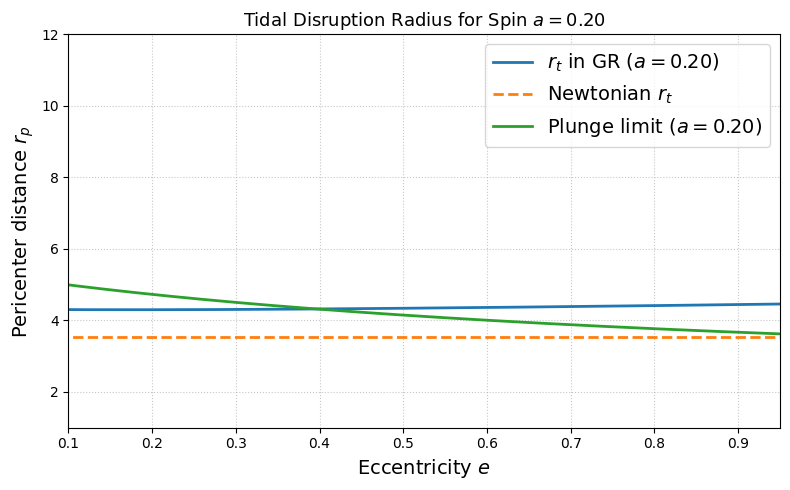

In [23]:
# Interpolate the computed results onto a finer grid
a_plunge_table = np.linspace(-0.99, 0.99, int(Num_a_plunge_table))
e_plunge_table = np.linspace(0.01, 0.96, int(Num_e_plunge_table))

from scipy.interpolate import RegularGridInterpolator

# Create a 2D interpolant for the tidal disruption radius r_t(a, e)
rp_rt_a_e_unstable_interpolant = RegularGridInterpolator(
    (a_plunge_table, e_plunge_table), 
    rp_rt, 
    method='cubic',          # Use cubic interpolation for smoother results (alternative: 'linear')
    bounds_error=False,      # Allow queries outside original bounds
    fill_value=None          # Return NaN for out-of-bounds points
)


# Define a high-resolution grid for visualization or further analysis
a_plunge_table = np.linspace(-0.99, 0.99, 200)
e_plunge_table = np.linspace(0.01, 0.96, 200)

# Build a refined rp_rt table by evaluating the interpolant on the new grid
rp_rt_table = np.zeros((len(a_plunge_table), len(e_plunge_table)))
for i in range(len(a_plunge_table)):
    for j in range(len(e_plunge_table)):
        rp_rt_table[i, j] = rp_rt_a_e_unstable_interpolant([a_plunge_table[i], e_plunge_table[j]])[0]

# Specify a target spin value for plotting
target_a_spin = 0.2

# Find the index of the closest available spin value in the grid
i_target = np.argmin(np.abs(a_plunge_table - target_a_spin))
actual_a_spin = a_plunge_table[i_target]  # Actual spin used (may differ slightly due to discretization)

# Extract the corresponding row: r_t as a function of eccentricity
rp_from_table = rp_rt_table[i_target, :]

# Compute reference curve: Newtonian tidal radius (constant)
reference_line = np.full_like(e_plunge_table, lambda_val**(-1/3))

# Compute analytic plunge orbit radius using the pre-defined solver
analytic_rp = solve_rp_function(actual_a_spin)(e_plunge_table)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(e_plunge_table, rp_from_table, '-', label=rf'$r_t$ in GR ($a = {actual_a_spin:.2f}$)', linewidth=2)
plt.plot(e_plunge_table, reference_line, '--', label=r'Newtonian $r_t$', linewidth=2)
plt.plot(e_plunge_table, analytic_rp, '-', label=rf'Plunge limit ($a = {actual_a_spin:.2f}$)', linewidth=2)

# Set axis limits
plt.xlim([0.1, 0.95])
plt.ylim([1, 12])

# Axis labels and title (in English with LaTeX formatting)
plt.xlabel('Eccentricity $e$', fontsize=14)
plt.ylabel('Pericenter distance $r_p$', fontsize=14)
plt.title(f'Tidal Disruption Radius for Spin $a = {actual_a_spin:.2f}$', fontsize=13)

# Legend and grid
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()

# Display the figure
plt.show()